# Introduction to TimeSeries Forecasting with ARIMA

In this notebook, we will explore various **ARIMA** models for TimeSeries forecasting. 

**ARIMA** stands for:
- Auto-Regressive
- Integrated
- Moving Average

With the ARIMA family of models, three numbers specify how the model runs: $$(p,d,q)$$

*Note that another (sometimes more general) name for the ARIMA family is SARIMAX. We will consider these names interchangeable.*

In [3]:
# Import the required packages

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
# import prophet

<AxesSubplot:xlabel='Month'>

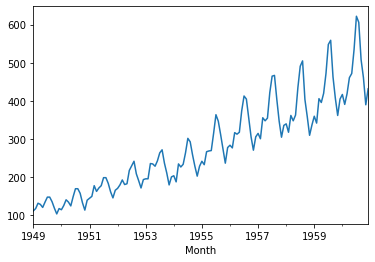

In [37]:
# Read the data and create the TimeSeries

df = pd.read_csv("airline_passengers.csv")
thousand_passengers = df['Thousands of Passengers']

thousand_passengers.index = pd.DatetimeIndex(df['Month'],freq = 'MS')
thousand_passengers.plot()

In [38]:
# Test train split 

train_data =  thousand_passengers[:'1958']
test_data = thousand_passengers['1959':]

### ARIMA(1,0,0) = first-order AutoRegressive model

In the first-order autoregressive model ARIMA(1,0,0), we run a regression model to predict what will happen in the next time step based on the most recent result.
$$ \hat{y}_t = [const] + [ar.L1] y_{t-1}$$

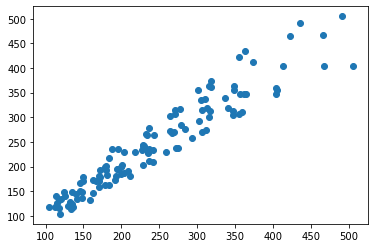

In [39]:
# Plot a scatter plot of y_t-1 against y_t

plt.scatter(train_data.shift(1),train_data)

In [40]:
model_100 = ARIMA(
    train_data,
    order = (1,0,0)
).fit()
model_100.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                  120
Model:                      ARIMA(1, 0, 0)   Log Likelihood                -573.198
Date:                     Fri, 03 Sep 2021   AIC                           1152.396
Time:                             12:26:29   BIC                           1160.759
Sample:                         01-01-1949   HQIC                          1155.792
                              - 12-01-1958                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        240.0003     51.849      4.629      0.000     138.377     341.623
ar.L1          0.9569      0.022     44.000      0.000       0.914       1.000
sigma2       808.3891     97.426      8.297      0.000     617.437     999.341
===================================================================================
Ljung-Box (L1) (Q):                  10.29   Jarque-Bera (JB):                 0.91
Prob(Q):                              0.00   Prob(JB):                         0.64
Heteroskedasticity (H):               6.86   Skew:                             0.13
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<AxesSubplot:xlabel='Month'>

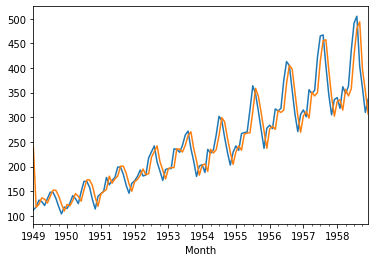

In [41]:
## Plot the training data and the model fitted values

train_data.plot()
model_100.fittedvalues.plot() 

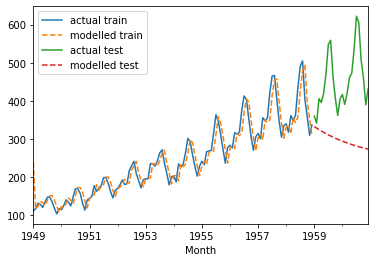

In [42]:
train_data.plot()
model_100.fittedvalues.plot(style='--')
test_data.plot()
model_100.forecast(len(test_data)).plot(style='--')
plt.legend(['actual train','modelled train','actual test','modelled test'])

Research Task: Why is the model forecast trending downwards? (Think about the model equation and parameters.)

In [43]:
# Average Squared Error for the train_data

squared_errors = (train_data - model_100.fittedvalues)**2
ase_train = squared_errors.sum()

In [44]:
# Average Squared Error for the test_data

squared_errors = (test_data - model_100.forecast(len(test_data)))**2
ase_test = squared_errors.sum()

In [45]:
model_results = {
    'ARIMA(1,0,0)': [ase_train, ase_test]    
}

In this model, the modelled data fits the train data well, but is a bad fit for the test data. You found out why in the research task above!

AutoRegressive models are similar to Simple Exponential Smoothing models and are not well suited to data with a trend. In the combined models, the Integrated part of the model allows for trends in the data.

However, as our model gets more complex, we will need to watch the number of parameters. In order for our model to be **robust** (trustworthy), we need to have at least around **30 data points per parameter**.

### ARIMA(0,1,0) = first-order Integrated model

In the first-order integrated model ARIMA(0,1,0), we run an integrated model to predict what will happen in the next time step based on the most recent result.
$$ \hat{y}_t - y_{t-1} = 0 $$

In [46]:
model_010 = ARIMA(
    train_data,
    order = (0,1,0)
).fit()
model_010.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                  120
Model:                      ARIMA(0, 1, 0)   Log Likelihood                -568.404
Date:                     Fri, 03 Sep 2021   AIC                           1138.809
Time:                             12:26:30   BIC                           1141.588
Sample:                         01-01-1949   HQIC                          1139.937
                              - 12-01-1958                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       824.8100     93.869      8.787      0.000     640.830    1008.790
===================================================================================
Ljung-Box (L1) (Q):                   9.81   Jarque-Bera (JB):                 3.46
Prob(Q):                              0.00   Prob(JB):                         0.18
Heteroskedasticity (H):               8.00   Skew:                            -0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<AxesSubplot:xlabel='Month'>

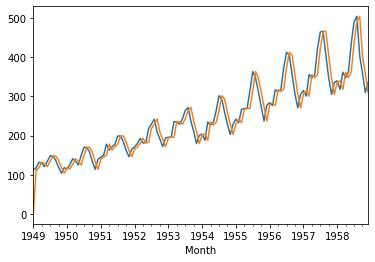

In [47]:
## Plot the training data and the model fitted values

train_data.plot()
model_010.fittedvalues.plot() 

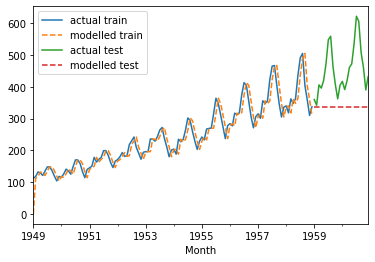

In [48]:
train_data.plot()
model_010.fittedvalues.plot(style='--')
test_data.plot()
model_010.forecast(len(test_data)).plot(style='--')
plt.legend(['actual train','modelled train','actual test','modelled test'])

In [49]:
# Average Squared Error for the train_data

squared_errors = (train_data - model_010.fittedvalues)**2
ase_train = squared_errors.sum()

In [50]:
# Average Squared Error for the test_data

squared_errors = (test_data - model_010.forecast(len(test_data)))**2
ase_test = squared_errors.sum()

In [51]:
model_results['ARIMA(0,1,0)']=[ase_train, ase_test]

A first-order Integrated model on it's own is pretty basic and very similar to a first-order AutoRegressive model. However, when we combine the integrated step with AR or MA, we allow for trends in the data. 

However, as our model gets more complex, we will need to watch the number of parameters. In order for our model to be **robust** (trustworthy), we need to have at least around **30 data points per parameter**.

### ARIMA(0,0,1) = first-order Moving Average model

In the first-order moving average model ARIMA(0,0,1), we run a moving average model to predict what will happen in the next time step based on the most recent result.
$$ \hat{y}_t = [const] + [ma.L1] (y_{t-1} - \hat{y}_{t-1}) $$

In [52]:
model_001 = ARIMA(
    train_data,
    order = (0,0,1)
).fit()
model_001.summary()

C:\Users\EoinMartyn\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                  120
Model:                      ARIMA(0, 0, 1)   Log Likelihood                -644.711
Date:                     Fri, 03 Sep 2021   AIC                           1295.422
Time:                             12:26:30   BIC                           1303.784
Sample:                         01-01-1949   HQIC                          1298.818
                              - 12-01-1958                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        246.0847      9.975     24.670      0.000     226.534     265.636
ma.L1          0.9738      0.048     20.497      0.000       0.881       1.067
sigma2      2650.8882    415.999      6.372      0.000    1835.546    3466.230
===================================================================================
Ljung-Box (L1) (Q):                  67.71   Jarque-Bera (JB):                 6.17
Prob(Q):                              0.00   Prob(JB):                         0.05
Heteroskedasticity (H):               1.57   Skew:                             0.52
Prob(H) (two-sided):                  0.16   Kurtosis:                         2.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<AxesSubplot:xlabel='Month'>

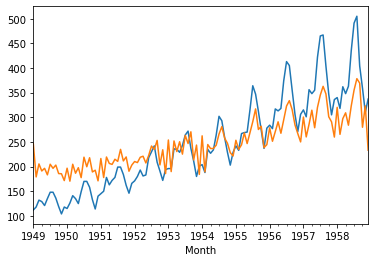

In [53]:
## Plot the training data and the model fitted values

train_data.plot()
model_001.fittedvalues.plot() 

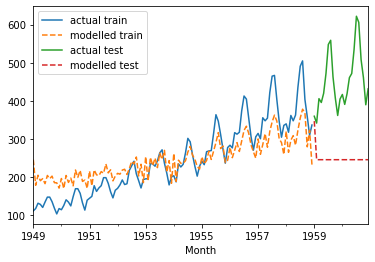

In [54]:
train_data.plot()
model_001.fittedvalues.plot(style='--')
test_data.plot()
model_001.forecast(len(test_data)).plot(style='--')
plt.legend(['actual train','modelled train','actual test','modelled test'])

In [55]:
# Average Squared Error for the train_data

squared_errors = (train_data - model_001.fittedvalues)**2
ase_train = squared_errors.sum()

In [56]:
# Average Squared Error for the test_data

squared_errors = (test_data - model_001.forecast(len(test_data)))**2
ase_test = squared_errors.sum()

In [57]:
model_results['ARIMA(0,0,1)'] = [ase_train, ase_test]

In this model, the modelled data fits the train data and test data badly! This seems to be because the data is trending upwards, while the model is centred around a certain value.

Similar to AutoRegressive models, Moving-Average models and are not well suited to data with a trend. In the combined models, the Integrated part of the model allows for trends in the data.

However, as our model gets more complex, we will need to watch the number of parameters. In order for our model to be **robust** (trustworthy), we need to have at least around **30 data points per parameter**.

### ARIMA(1,1,2)

In the combined ARIMA(1,1,2) model, we first take differencing and then use autoregressive and moving average components to model the data.

In [58]:
model_112 = ARIMA(
    train_data,
    order = (1,1,2)
).fit()
model_112.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                  120
Model:                      ARIMA(1, 1, 2)   Log Likelihood                -555.050
Date:                     Fri, 03 Sep 2021   AIC                           1118.099
Time:                             12:26:31   BIC                           1129.216
Sample:                         01-01-1949   HQIC                          1122.614
                              - 12-01-1958                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5611      0.110      5.109      0.000       0.346       0.776
ma.L1         -0.3213      0.107     -3.008      0.003      -0.531      -0.112
ma.L2         -0.4879      0.087     -5.604      0.000      -0.658      -0.317
sigma2       655.6251     91.814      7.141      0.000     475.674     835.576
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 0.15
Prob(Q):                              0.83   Prob(JB):                         0.93
Heteroskedasticity (H):               6.84   Skew:                            -0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<AxesSubplot:xlabel='Month'>

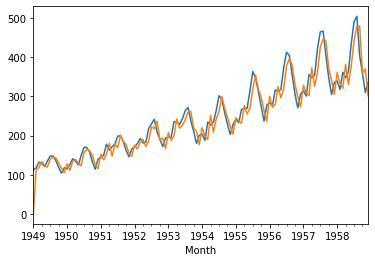

In [59]:
## Plot the training data and the model fitted values

train_data.plot()
model_112.fittedvalues.plot() 

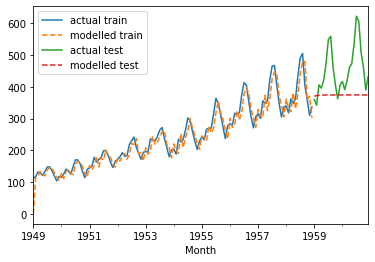

In [60]:
train_data.plot()
model_112.fittedvalues.plot(style='--')
test_data.plot()
model_112.forecast(len(test_data)).plot(style='--')
plt.legend(['actual train','modelled train','actual test','modelled test'])

In [61]:
# Average Squared Error for the train_data

squared_errors = (train_data - model_112.fittedvalues)**2
ase_train = squared_errors.sum()

In [62]:
# Average Squared Error for the test_data

squared_errors = (test_data - model_112.forecast(len(test_data)))**2
ase_test = squared_errors.sum()

In [63]:
model_results['ARIMA(1,1,2)']=[ase_train, ase_test]

### ARIMA(1,2,1)

In the combined ARIMA(1,2,1) model, we first take differencing twice and then use autoregressive and moving average components to model the data.

In [64]:
model_121 = ARIMA(
    train_data,
    order = (1,2,1)
).fit()
model_121.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                  120
Model:                      ARIMA(1, 2, 1)   Log Likelihood                -560.986
Date:                     Fri, 03 Sep 2021   AIC                           1127.973
Time:                             12:26:32   BIC                           1136.285
Sample:                         01-01-1949   HQIC                          1131.348
                              - 12-01-1958                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2938      0.110      2.665      0.008       0.078       0.510
ma.L1         -0.9998      6.123     -0.163      0.870     -13.002      11.002
sigma2       761.4610   4692.973      0.162      0.871   -8436.597    9959.519
===================================================================================
Ljung-Box (L1) (Q):                   0.38   Jarque-Bera (JB):                 5.62
Prob(Q):                              0.54   Prob(JB):                         0.06
Heteroskedasticity (H):               7.13   Skew:                            -0.07
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<AxesSubplot:xlabel='Month'>

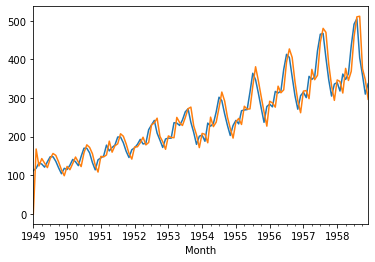

In [65]:
## Plot the training data and the model fitted values

train_data.plot()
model_121.fittedvalues.plot() 

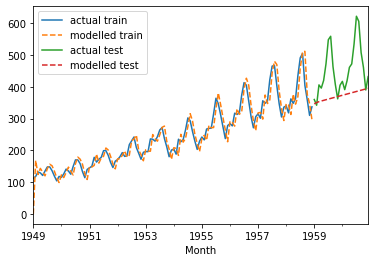

In [66]:
train_data.plot()
model_121.fittedvalues.plot(style='--')
test_data.plot()
model_121.forecast(len(test_data)).plot(style='--')
plt.legend(['actual train','modelled train','actual test','modelled test'])

In [67]:
# Average Squared Error for the train_data

squared_errors = (train_data - model_121.fittedvalues)**2
ase_train = squared_errors.sum()

In [68]:
# Average Squared Error for the test_data

squared_errors = (test_data - model_121.forecast(len(test_data)))**2
ase_test = squared_errors.sum()

In [69]:
model_results ['ARIMA(1,2,1)']= [ase_train, ase_test]   

In this model, the modelled data fits the train data well and is starting to get better at fitting the test data - using the combined Integrated and AutoRegressive, Moving-Average models has taken account of the trend in the data. But, it's still missing something in the forecast. 

This seems to be because the data has a seasonal pattern, while the model doesn not. In the SARIMA models on the next notebook, we will add a Seasonality component to our model so that it better fits the data.

However, as our model gets more complex, we will need to watch the number of parameters. In order for our model to be **robust** (trustworthy), we need to have at least around **30 data points per parameter**.

---
<a id="summary"></a>
# Summary of results

In [70]:
for model, result in  model_results.items():
    print('---')
    print(model)
    print('\t Train ASE:',format(result[0], ",.0f"))
    print('\t Test ASE:', format(result[1], ",.0f"))

---
ARIMA(1,0,0)
	 Train ASE: 111,987
	 Test ASE: 734,262
---
ARIMA(0,1,0)
	 Train ASE: 110,695
	 Test ASE: 452,622
---
ARIMA(0,0,1)
	 Train ASE: 334,569
	 Test ASE: 1,141,129
---
ARIMA(1,1,2)
	 Train ASE: 90,611
	 Test ASE: 279,463
---
ARIMA(1,2,1)
	 Train ASE: 106,359
	 Test ASE: 272,762


In [ ]:
# Exercise: Add the number of data points per parameter to the model_results dictionary for each model



Research Task: Choose the most suitable model and justify your choice.

In [71]:
# Exercise: Build the final model using all the data and print the model summary



In [ ]:
# Exercise: Plot the data and the forecast for a 36 month period

